# Ejemplo 1:

Consideremos el siguiente PVI con $y=y(x)$:

$$\begin{cases}
y'&=2xy\\
y(0)&=2
\end{cases}
$$


Lo podemos resolver con los métodos conocidos ? Hallar la solución y graficarla

In [26]:

#paquetes
import numpy as np #manejo de arreglos
import matplotlib.pyplot as plt #gráficos

plt.rcParams["figure.figsize"] = (10,7) #tamaño de los gráficos: ancho x alto

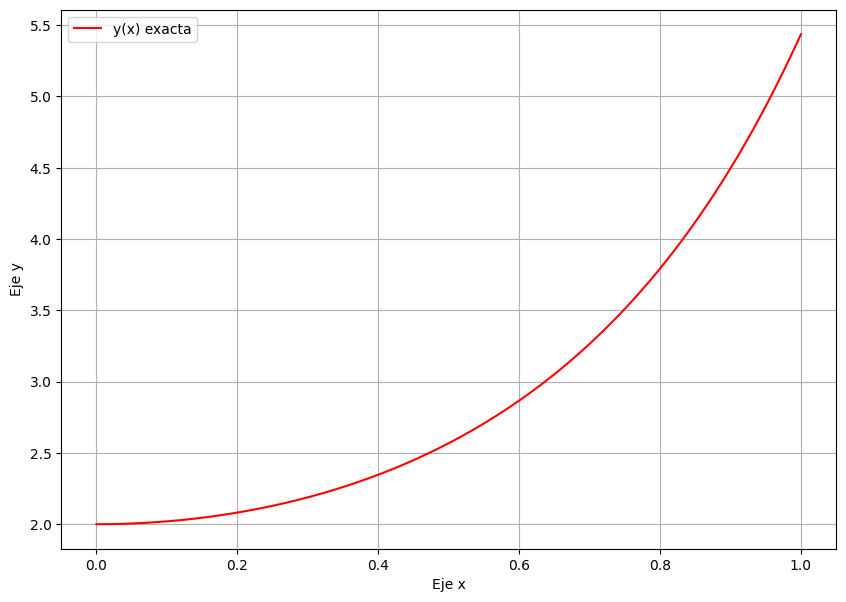

In [27]:
# Definimos valores de x en donde vamos a evaluar la función para graficar los pares ordenados
x_exacta = np.linspace(0,1,1000)

# Definimos la funcion que queremos graficar
y_exacta = 2*np.exp(x_exacta**2)

# Grafico
plt.plot(x_exacta, y_exacta, 'r', label='y(x) exacta')
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid()
plt.legend()

# Método de Euler:

Queremos definir dos suceciones:


Dados $x_0 , y_0 $ dato inicial
$$ x_{k+1} = x_k +h $$ y
$$ y_{k+1} = y_k + h f(x_k, y_k) $$ donde $k \geq 1$, $h$ pequeño , hasta una cantidad de veces  $N$, donde obtendremos $x_N$, así la solución buscada quedará definida en $I= [x_0, x_N]$ y $ h = \frac{x_N - x_0}{N}$.


Observar relación entre $ x_0, x_N , N \, \mbox{y}     \, h$

In [28]:
# 1ero Definamos la funcion f(x,y) del lado derecho de la ED, la llamareemos func_f y llamamos y_deriv a la salida
def f_der(x,y):
  yderiv = 2*x*y
  return yderiv



#2do Definimos Metodo_Euler como una funcion queremos que retorne las dos suc x_n e y_n

def Metodo_Euler(x0, y0, f, N, xN): # pensar bien de que depende hay muchas maneras..esta es una ...

  h=(xN-x0)/N # calcula el paso h
  x_values = np.arange(x0, xN +h, h) # dejo todos los valores x en este vector (notar que arrange ya hace esto)  stop en xN +h para que agarre a x=xN
  #x_values ya tien ela suc de los x. y_values es un poco mas dificil
  y_values=[y0] # inicializo
  #arranco la recursión con índice j
  for j in range(1,N +1): # tanto range omo arange son abiertos en el ultimo numero
    yj=y_values[-1] #el ultimo valor de y_values
    xj=x0+(j-1)*h # con yj y xj puedo calcular f
    y_values=np.append(y_values, yj + h*f(xj,yj))
  return x_values, y_values, h



Aplicar el Método de Euler al PVI del Ejemplo 1 con N=100 en el intervalo $[0,1]$

Cuanto vale h?

In [30]:
#Aplicamos el  Metodo_Euler a la funcion que definimos como lado derecho de la EDO con N=100 y xN=1
#datos de entrada: x0=0, y0=2, f_der, , N=100, xN=1
x_values,y_values,h = Metodo_Euler(0,2,f_der,100, 1) # como salida nos da las dos sucesiones xn, yn, h

'''
Observar algunas longitudes como N, x_values, y_values, xN, h
'''

'\nObservar algunas longitudes como N, x_values, y_values, xN, h \n'

Graficar la sol numerica calculada con el Método de Euler

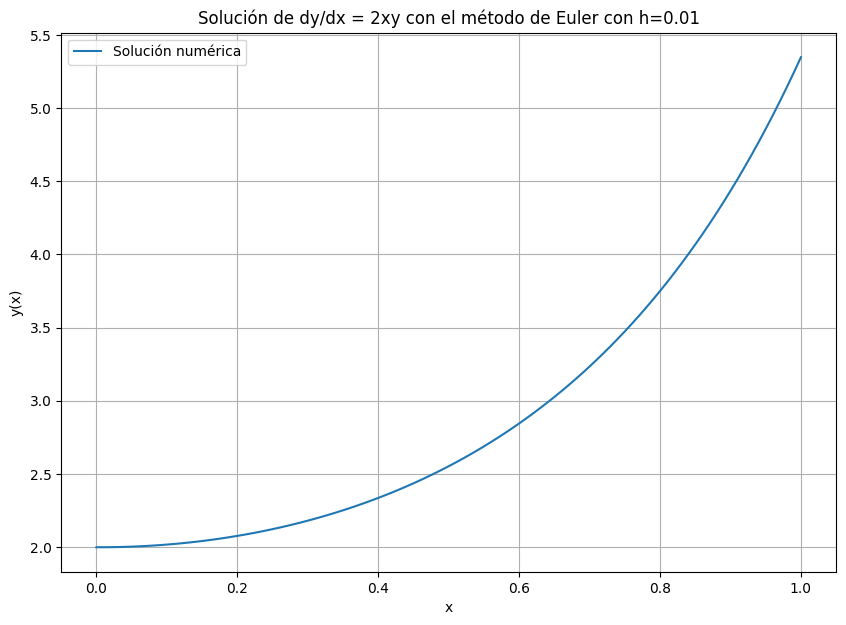

In [31]:

#plt.plot(x_values, y_values, '.', label='Solución numérica') # HACE PUNTOS DISCRETOS
plt.plot(x_values, y_values, label='Solución numérica')# interpola y une los puntos
plt.title('Solución de dy/dx = 2xy con el método de Euler con h={}'.format(h))
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid()
plt.show()

Graficar la sol exacta  y la solucion obtenida con el Metodo de Euler en un mismo sistema de ejes cartesianos.

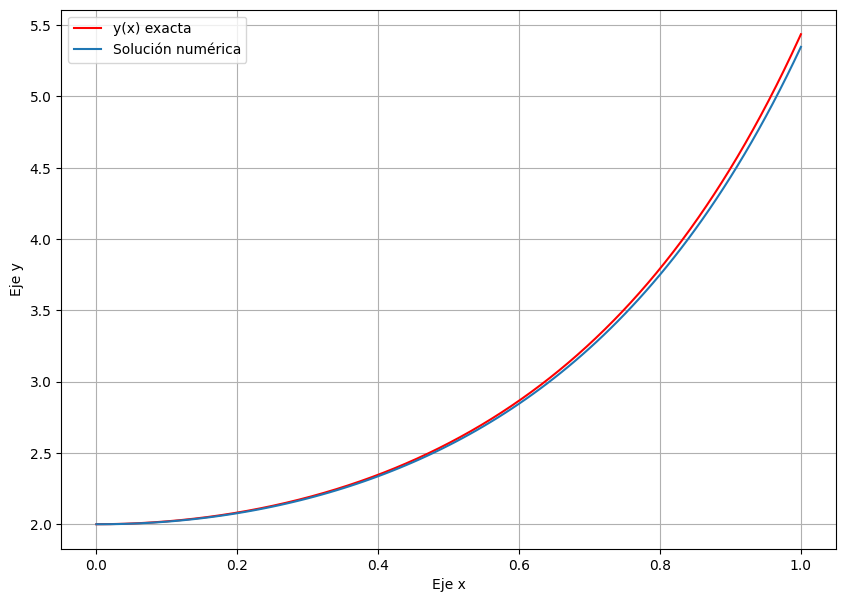

In [32]:

plt.plot(x_exacta, y_exacta, 'r', label='y(x) exacta')
plt.plot(x_values, y_values, label='Solución numérica')# interpola y une los puntos
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid()
plt.legend()







Dar el valor de h

In [33]:
h

0.01

Programemos de **otra forma** el método de Euler haciendo que dependa de h como argumento de entrada para poder controlar la finitud del "paso h"


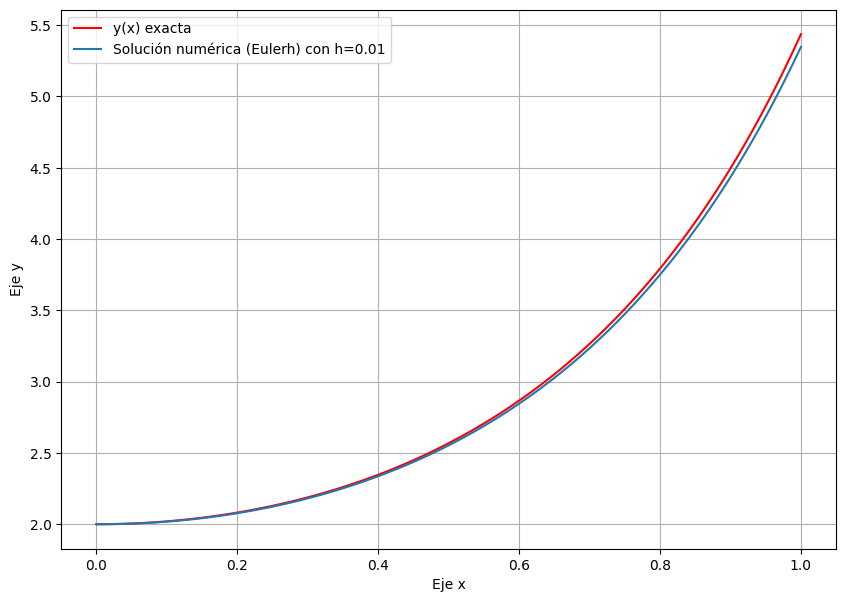

In [35]:

def Euler_h(x0, y0, xN, f, h): # le doy como entrada el el ultimo punto del intervalo donde quiero solución (x_N) y h
  N=(xN-x0)/h
  N=int(N) # N debe ser entero
  x=np.linspace(x0,xN,N+1) # da N+1 cantidad de puntos equisdistantes en [x0, xN] (incluidos los extremos)
  y=np.zeros(N+1)
  y[0]=y0
  for i in range(1,N+1):
    y[i]=y[i-1] + h*f(x[i-1],y[i-1])
  return(x,y, h, N)


# aplico la funcion Euler_h con el mismo h del Euler 1
xx, yy , h,  N= Euler_h(0, 2, 1, f_der, h)

# Grafico
plt.plot(x_exacta, y_exacta, 'r', label='y(x) exacta')
plt.plot(xx, yy, label='Solución numérica (Eulerh) con h={}'.format(h))# interpola y une los puntos
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid()
plt.legend()


Ahora graficamos para distintos valores de h. Por ejemplo h = 0.2, 0.1 y 0.01.

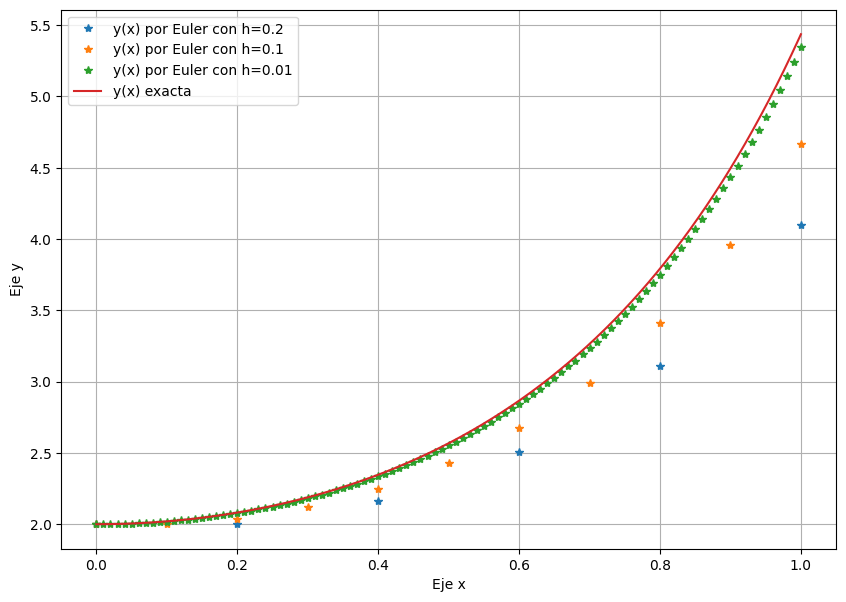

In [36]:
#1ero defino vector de h
hs= [0.2, 0.1, 0.01]
#hs= [0.2]
#ahora un for para graficar con cada h

for h in hs:
  x, y , h, N= Euler_h(0, 2, 1, f_der, h)
  plt.plot(x ,y, '*', label='y(x) por Euler con h={}'.format(h)) #grafico adentro del for con puntos para que no interpole y ver diferencias

#afuera del for graficamo sol exacta

plt.plot(x_exacta, y_exacta, label='y(x) exacta')
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.grid()

plt.legend()




---



---



# Ejercicios:


**Ejercicio** 1: Hacer el  Ej 5 de la P0

**Ejercicio** 2: hacer el 6 de la práctica 0 (método de Euler modificado: hay que programarlo antes, modificando el original).

# Euler no es tan bueno...

Consideremos la ecuación:

$$\begin{cases}
y' &= \lambda y \\
 y(0)  &= 1
\end{cases}$$



a.   Resolver usando Euler_h para $λ=15 $ en el intervalo $I=[0,10]$


b. Resolver a mano tambien y graficar ambas




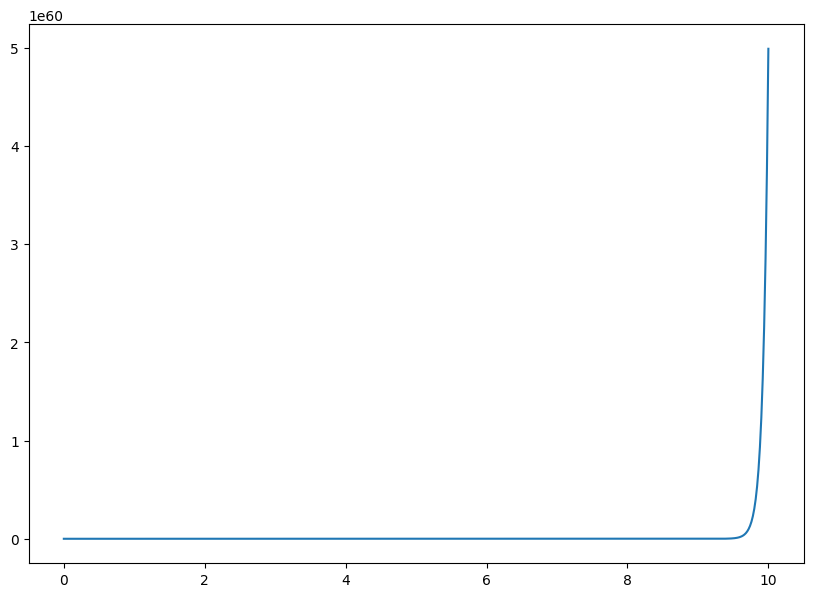

In [39]:
lam=15

#defino funcion lado derecho
def func(x,y):
  yderiv = lam*y
  return yderiv

#datos
x0=0
xN=10
y0=1

#x, y, h, N= Euler_h( x0,y0, xN,func, h) asi se llamaba a la funcio Euler_h

hs= 0.01 # con este h y xN=10  el N=100


x, y, h, N = Euler_h( 0, 1, 10,func, h )
plt.plot(x ,y, label='y(x) por Euler con h={}'.format(h))



In [40]:
# algunos numeritos
N, len(x), x[-1], y[-1], h , xN

(1000, 1001, 10.0, 4.987011315276332e+60, 0.01, 10)

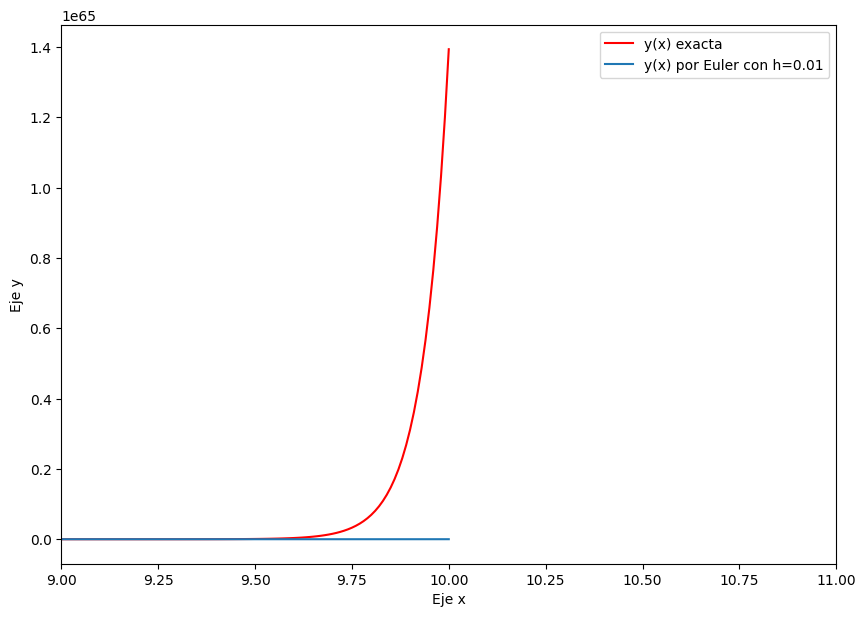

In [41]:
#Graficamos la sol exacta y la calculada con Euler_h solo en el intervalo (9, 11) para ver bien como se despegan una de la otra
x_graf = np.linspace(0,10,1001)
y_sol_exacta =  np.exp(lam*x_graf)
plt.plot(x_graf, y_sol_exacta, 'r', label='y(x) exacta')
plt.plot(x ,y, label='y(x) por Euler con h={}'.format(h))
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.xlim(9, 11)
plt.legend()


Calcular la sol exacta en $x=10$ y la sol de Euler en $x=10 $

In [42]:
 x[-1], y[-1], x_graf[-1], y_sol_exacta[-1]

(10.0, 4.987011315276332e+60, 10.0, 1.3937095806663797e+65)

In [43]:
# Elegantemente:

print(f"La solución exacta pasa por el punto: ({x_graf[-1]}, {y_sol_exacta[-1]})")
print(f"La solución de Euler_h pasa por el punto: ({x[-1]}, {y[-1]})")

La solución exacta pasa por el punto: (10.0, 1.3937095806663797e+65)
La solución de Euler_h pasa por el punto: (10.0, 4.987011315276332e+60)


Euler propaga mucho error en tiempos grandes !

# Solver de Python

Documetación:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

En Python tenemos el comando **solve_ivp** para resolver PVI. Funciona bajo la libreria scipy.integrate, asi que primero debemos importalo desde ahí.
Tiene muchos parâmetros tanto de salida como de entrada que podrán encontra en la documentación. Veamos como se usa con un ejemplo.



Usemos **solve_ivp** para reoslver el ejemplo anterior donde Euler falla

$$\begin{cases}
y' &= \lambda y \\
 y(0)  &= 1
\end{cases}$$

Resolver usando  **solve_ivp** para $λ=15 $ en el intervalo $I=[0,10]$






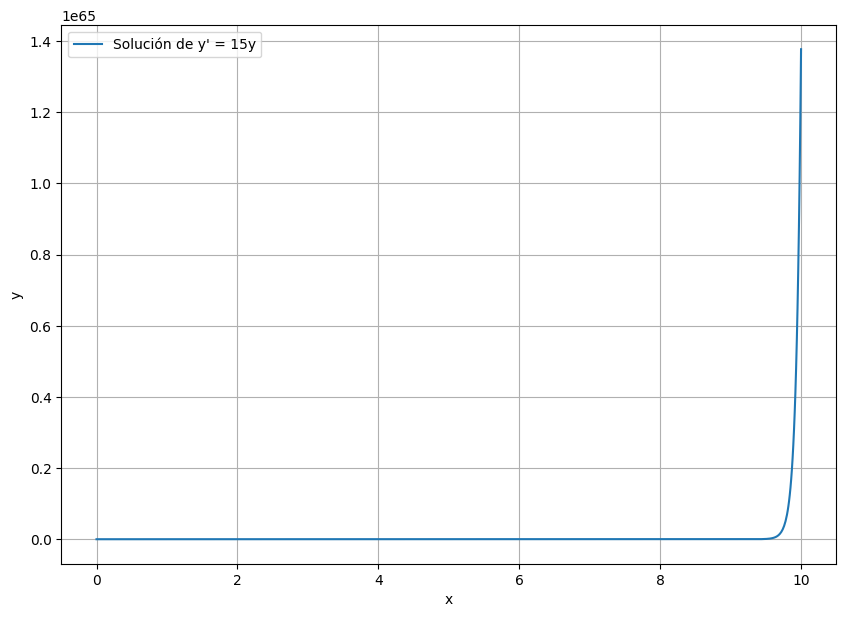

"\nObservaciones :\n1- dense_output = True: Si se debe calcular una solución continua. El valor predeterminado es Falso.\n2- method: Método de integración a utilizar: 'RK45' (predeterminado): método explícito de Runge-Kutta de orden 5/4\n3- Resuelve en I=[x0, xN] donde dato inical es (x0, y0)\n"

In [46]:
#paquetes
import numpy as np
from scipy.integrate import solve_ivp


#Solución por solve_ivp
lam=15
# definimos la función
def func(x,y):
    dy = lam*y
    return dy

# condiciones iniciales e intervalo.

x0 = 0 #tiempo inicial
y0 = [1] # condicion inical en forma de []
xf = 10 #tiempo final

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solution = solve_ivp(func,[x0, xf] , y0, dense_output = True ) # la saco continua cn el dense output

# Defino x y evaluo los y para graficar
x_values = np.linspace(x0, xf, 1000)   # defino x
y_values = solution.sol(x_values) #Evalúo los y solución

# Graficar la solución
plt.plot(x_values, y_values.T, label='Solución de y\' = 15y') # para graficar hay que transponer por como da la salida el solver

plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

'''
Observaciones :
1- dense_output = True: Si se debe calcular una solución continua. El valor predeterminado es Falso.
2- method: Método de integración a utilizar: 'RK45' (predeterminado): método explícito de Runge-Kutta de orden 5/4
3- Resuelve en I=[x0, xN] donde dato inical es (x0, y0)
'''




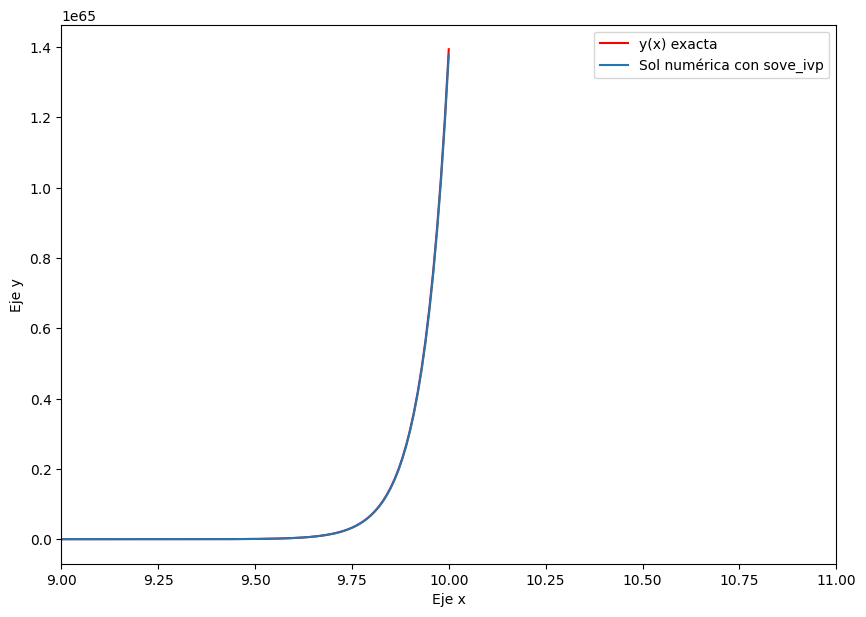

In [47]:
#Graficamos la sol exacta y la calculada con solve_ivp
x = np.linspace(x0, xf, 1000)
y_exacta =  np.exp(lam*x)
plt.plot(x, y_exacta, 'r', label='y(x) exacta')
plt.plot(x, y_values.T, label= 'Sol numérica con sove_ivp')
plt.xlabel('Eje x')
plt.ylabel('Eje y')
plt.xlim(9, 11)
plt.legend()


Aplausos!!! 👏

# Mas Ejercicios:

Vamos a trabajar con la siguiente ecuación:

\begin{cases}
y' =& 0.1\sqrt y +0.4x^2\\
y(2) =& 4
\end{cases}
a. Observar que no podemos resolver a mano

b. Usando la página (https://homepages.bluffton.edu/~nesterd/apps/slopefields.html ) graficar el campo de pendientes.

c. Observar los ejes $x$ e $y$  y arreglarlos si fuera necesario

d. En la pagina del campos de pendientes dar la condición inicial (2,4).

e. Resolver usando  solve_ivp




In [ ]:
3**2

9

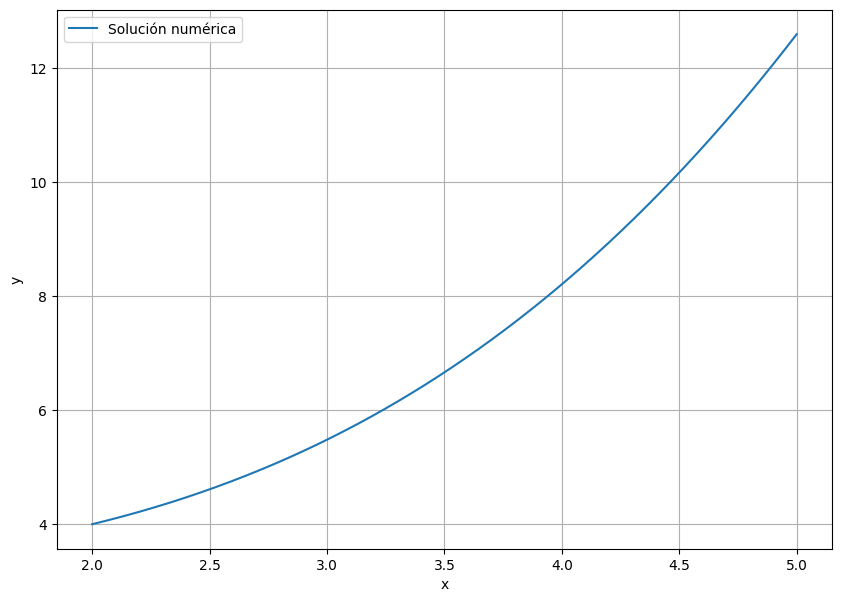

In [48]:
# definimos la función
def func(x,y):
    dy = 0.1*np.sqrt(y) +0.2*x**2
    return dy

# condiciones iniciales e intervalo.

x0 = 2 #tiempo inicial
y0 = [4] # condicion inical
xf =  5 #tiempo final

# solve_ivp recibe: función, intervalo de tiempo y condicione iniciales
solucion = solve_ivp(func, [x0, xf], y0, dense_output = True) # llamamos solucion a toda la salida del solve

# Defino x y evaluo los y para graficar
x_values = np.linspace(x0, xf, 1000)   # defino x
y_values = solucion.sol(x_values) #Evalúo los y solución



# Graficar la solución
plt.plot(x_values, y_values.T, label='Solución numérica') # para graficar hay que transponer por como da la salida el solver


plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

